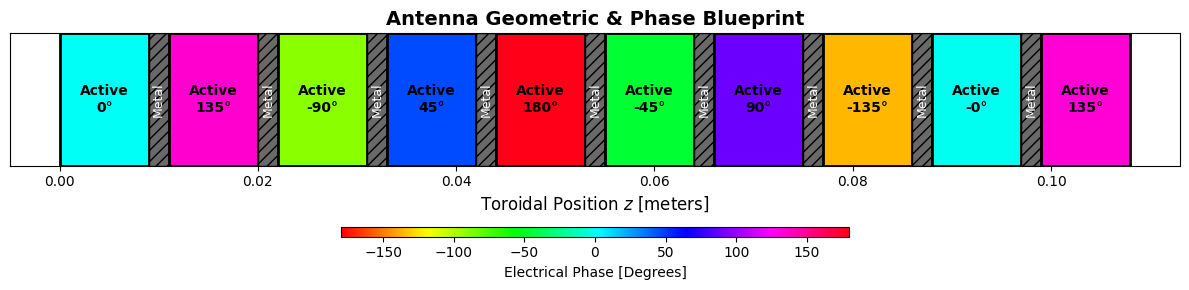

In LHCoupling class: n_para: 2.8, n_perp_p: 1.35e+01+0.00e+00j, n_perp_m: 0.00e+00+2.54e+00j


In [1]:
%load_ext autoreload
%autoreload 2

# Importing the modules

import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
# from solver_2DHcurl_1DH1_Copie import *
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

from pathlib import Path

import Antenna_Desc_n_Plot as antenna

antenna_grill = not None
if antenna_grill != None:
    antenna_grill = antenna.AntennaGrill(b_active=0.009, d_septa=0.002, d_gap=0.010)
    antenna_grill.add_module(num_active=10, delta_phi_deg=135, is_PAM=False)

    instructions = antenna_grill.generate_mesh_instructions()
    antenna.plot_antenna_blueprint(instructions)


mode = "FULL_2D" # "RADIAL_ONLY" or "FULL_2D"
solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, mode, antenna_grill)

In [2]:
mesh = solver.build_mesh_with_PMLs()
solver.build_physics_Stix_B_field()

GF_E_field, _, Gamma_R, Gamma_T, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, mode)

mode: FULL_2D
==== 
Lx_plasma: 2.00e-02m,   Lx_pml: 3.00e-02m,    Lx_tot: 5.00e-02m
Lx_wg = 3.00e-02m
Lz_antenna: 1.08e-01m, Lz_wall: 2.00e-02m
Lz_plasma: 1.48e-01m, Lz_pml: 2.93e-02m, Lz_tot: 2.07e-01m
==== 
n_∥: 2.8,   λ_∥: 2.93e-02m 
n_⟂⁺:13.46+0.00j, λ_⟂⁺: 6.02e-03m 
n_⟂-:0.00+2.54j, λ_⟂⁻: 3.18e-02m
==== 
n_index_meshing: 13.46 
λ_meshing: 6.02e-03m 
maxh_plasma: 6.02e-04m
==== 
Lz_wall: 2.00e-02m 
Lz_source: 1.08e-01m
==== 
PPW_pml: 50.0 
Sx_norm:2.50e+00, maxh_pml_radial: 4.82e-05 
Sz_norm_max: 4.12e+00, maxh_pml_toroidal: 2.92e-05 
maxh_pml_corner: 2.50e-05
[DOMAIN 2D DEFINED AND GLUED]
[MESH GENERATED !]
==== 
#DoFs = 3438020
len(instruction): 19
z_start: 0.02, z_end: 0.028999999999999998, E_val: (10+0j)
z_start: 0.031, z_end: 0.04, E_val: (-7.071067811865475+7.0710678118654755j)
z_start: 0.042, z_end: 0.051000000000000004, E_val: (-1.8369701987210296e-15-10j)
z_start: 0.053000000000000005, z_end: 0.062000000000000006, E_val: (7.071067811865477+7.071067811865474j)
z_start: 0.06

In [3]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
# run_folder_tot_path = "/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/" + run_folder_path
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260619_084930
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260619_084930


--- Extracting 2D Wave Map ---
[run 2D E map]
Lx_plasma: 2.00e-02m, Lx_pml: 3.00e-02m, Lx_tot: 5.00e-02m
Lz_plasma: 1.48e-01m, Lz_pml: 2.93e-02m, Lz_tot: 2.07e-01m
params recover in run_2D_wave_map
  --> Safely interpolating FEM fields onto structured grid...
In LHCoupling class: n_para: 2.8, n_perp_p: 1.35e+01+0.00e+00j, n_perp_m: 0.00e+00+2.54e+00j
PP_run_n_save: n_para: 2.8, n_perp_p: 1.35e+01+0.00e+00j, n_perp_m: 0.00e+00+2.54e+00j
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260619_084930/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui
PRINT H5 CONTENT:
 Lx_plasma: 2.00e-02
 Lx_pml: 3.00e-02
 Lx_tot: 5.00e-02
 Lz_plasma: 1.48e-01
 Lz_pml: 2.93e-02
 Lz_tot: 2.07e-01
 P_ideal: 8.22e-01
 P_in_net: 1.25e-02
 P_out_R: 1.57e-03
 P_out_T_left: 6.04e-03
 P_out_T_right: 6.04e-03
 k_para: -2.14e+02
 k_perp_p: -1.04e+03+0.00e+00j
 n_para: 2.76e+00
 peak_x_T: 1.49e-03
 peak_z_R: 1.70e-02
 window_size_radial: 9.03e-03
 window_siz

/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/PP_Plot_and_Load.py:182: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fontsize=12, ncol=2, framealpha=0.9)


--- Plot saved to /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260619_084930/Ez_map.png ---


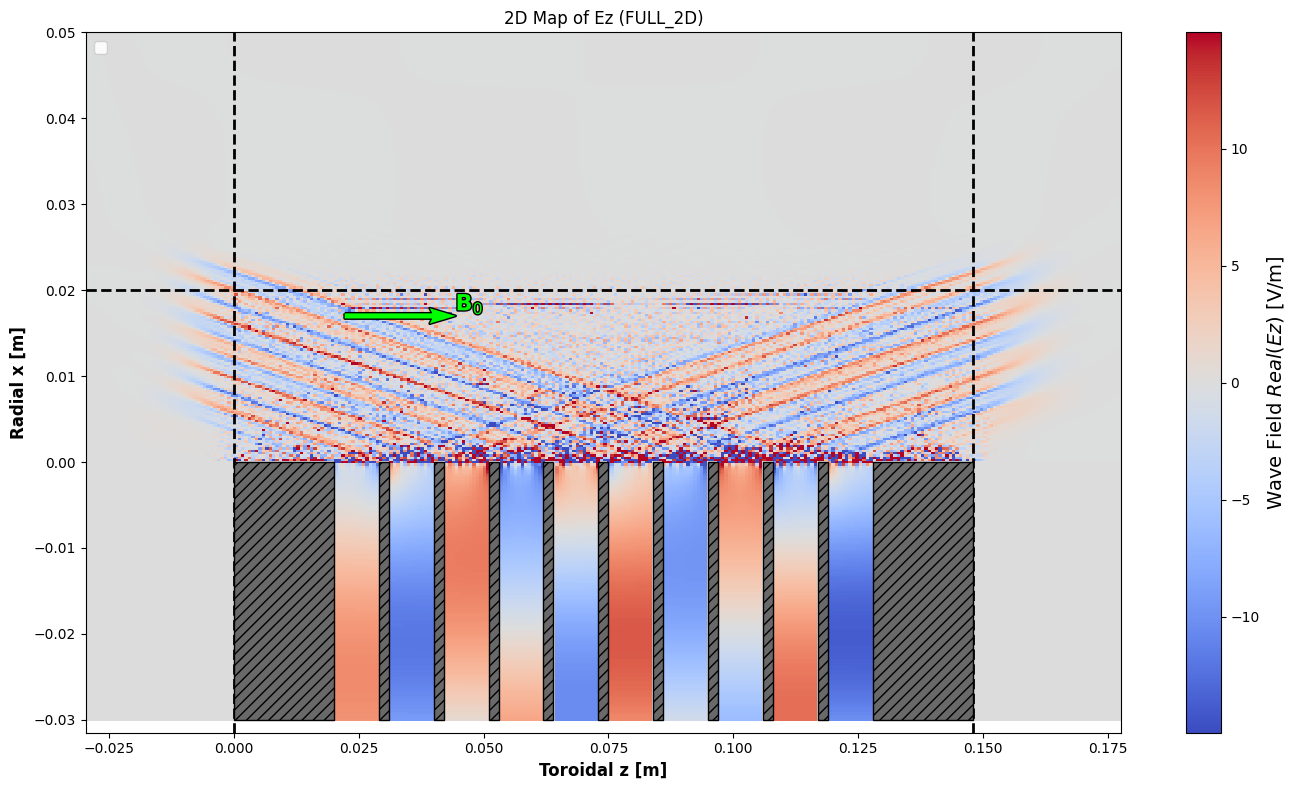

In [4]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, mode, antenna_grill, diag_data)
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 
# Plot E field 2D map and save it in the same folder: Run_XXX 
Lx_wg = cfg.DOMAIN.get('Lx_wg', 0.03)
Lz_wall = cfg.DOMAIN.get('Lz_wall', 0.02)

pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, mode, component='Ez', value_type='real',
                         antenna_grill=antenna_grill, Lx_wg=Lx_wg, Lz_wall=Lz_wall, plot_poynting=False, show_windows=False, Poynting_box=False)

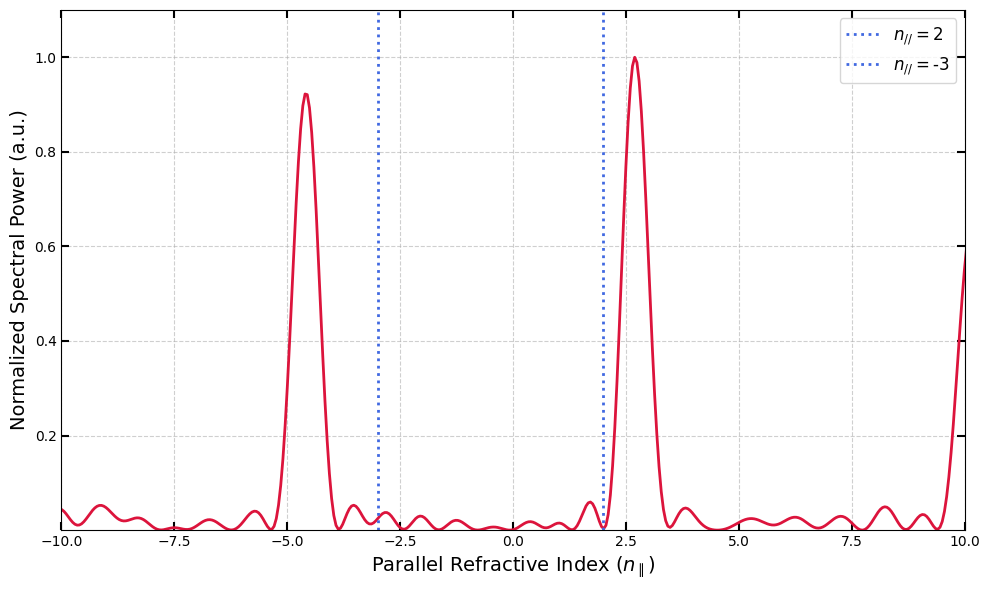

In [5]:
# Test n_para spectrum

n_para_array, power_spectrum = pp_plot.plot_n_para_spectrum(mesh, GF_E_field, cfg, mode, x_eval=0.001)


In [6]:
import os
import datetime
import numpy as np
import h5py
import copy
import gc
from ngsolve import *
from solver_2DHcurl_1DH1 import LHCouplingSolver_2DHcurl_1DH1

def run_1D_coherence_scan_and_save(base_cfg, scan_groups, n_para_list, save_dir="Results"):
    """
    Runs a 1D Radial PML scan across multiple n_para values for various parameters.
    Extracts SWR Gamma and Poynting Gamma, and saves all data to an HDF5 file.
    """
    print("===================================================================")
    print("  STARTING 1D POYNTING/SWR COHERENCE SCAN (HDF5 EXPORT)")
    print("===================================================================")
    
    os.makedirs(save_dir, exist_ok=True)
    
    # Create a unique timestamped H5 file
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    h5_filename = os.path.join(save_dir, f"1D_Coherence_Scan_{timestamp}.h5")
    
    with h5py.File(h5_filename, 'w') as h5f:
        # Save global metadata
        h5f.attrs['Simulation_Type'] = "1D_Radial_PML_Coherence"
        h5f.attrs['Date'] = timestamp
        h5f.attrs['Base_Freq_GHz'] = base_cfg['WAVE']['freq_LH'] / 1e9
        
        for group_name, (param_values, param_name) in scan_groups.items():
            print(f"\n---> Scanning Group: {group_name} ({param_name})")
            
            # Create H5 Group for this specific parameter scan
            grp = h5f.create_group(group_name)
            grp.attrs['param_name'] = param_name
            grp.create_dataset('param_values', data=param_values, compression="gzip")
            
            for n_para_val in n_para_list:
                print(f"  >> Evaluating n_para = {n_para_val}")
                
                gamma_sq_swr_array = []
                gamma_sq_poynting_array = []
                
                for val in param_values:
                    scan_cfg = {}
                    for key, value in base_cfg.items():
                        if isinstance(value, dict) and not key.startswith('__'):
                            scan_cfg[key] = copy.deepcopy(value)
                    
                    # Inject parameters
                    scan_cfg['WAVE']['n_para'] = n_para_val
                    
                    if param_name in ['Sx_r', 'Sx_im', 'px', 'ppw_pml']:
                        scan_cfg['PML'][param_name] = val
                    elif param_name == 'Lx_pml_ratio':
                        # Compute exact physics roots for this specific n_para
                        c0, freq = scan_cfg['CONST']['c0'], scan_cfg['WAVE']['freq_LH']
                        lambda0 = c0 / freq
                        temp_solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, mode="RADIAL_ONLY")
                        _, n_perp_p, _ = temp_solver.compute_physics_parameters()
                        del temp_solver
                        
                        scan_cfg['DOMAIN']['Lx_pml'] = val * (lambda0 / np.abs(n_perp_p.real))
                        scan_cfg['DOMAIN']['Lx_tot'] = scan_cfg['DOMAIN']['Lx_plasma'] + scan_cfg['DOMAIN']['Lx_pml']

                    # Run Solver
                    solver, mesh, gfu = None, None, None
                    gamma_sq_swr, gamma_sq_poynting = np.nan, np.nan
                    
                    try:
                        solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, mode="RADIAL_ONLY")
                        solver.build_physics_Stix_B_field()
                        mesh = solver.build_mesh_with_PMLs()
                        
                        gfu, _, Gamma_R, _, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, mode="RADIAL_ONLY")
                        
                        # Extract Metrics
                        gamma_sq_swr = Gamma_R**2
                        P_out_R = max(diag_data['P_out_R'], 1e-15)
                        P_ideal = max(diag_data['P_ideal'], 1e-15)
                        gamma_sq_poynting = max(1.0 - (P_out_R / P_ideal), 1e-12) # Floor at 1e-12 for log plotting
                        
                    except Exception as e:
                        print(f"     [Val = {val:.4e}] -> SOLVER FAILED: {e}")
                        
                    finally:
                        gamma_sq_swr_array.append(gamma_sq_swr)
                        gamma_sq_poynting_array.append(gamma_sq_poynting)
                        
                        if mesh is not None: del mesh
                        if gfu is not None: del gfu
                        if solver is not None: del solver
                        gc.collect()
                
                # Save data for this specific n_para
                subgrp = grp.create_group(f"n_para_{n_para_val}")
                subgrp.attrs['n_para_val'] = n_para_val
                subgrp.create_dataset('gamma_sq_swr', data=gamma_sq_swr_array, compression="gzip")
                subgrp.create_dataset('gamma_sq_poynting', data=gamma_sq_poynting_array, compression="gzip")
                
    print(f"\n[SUCCESS] All data written to: {h5_filename}")
    return h5_filename


In [7]:
import h5py
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_1D_coherence_from_h5(h5_filepath, save_dir="Results"):
    """
    Reads a 1D Coherence HDF5 file and generates publication-grade plots overlaying 
    Poynting Flux (lines) and SWR (scatter) across multiple n_para values.
    """
    print(f"--- Generating Plots from {h5_filepath} ---")
    os.makedirs(save_dir, exist_ok=True)
    
    with h5py.File(h5_filepath, 'r') as h5f:
        # Iterate over every scanned parameter group
        for group_name in h5f.keys():
            grp = h5f[group_name]
            param_name = grp.attrs['param_name']
            param_values = grp['param_values'][:]
            
            # Setup Plot
            fig, ax = plt.subplots(figsize=(10, 7))
            
            # Gather n_para sub-groups and sort them numerically
            n_para_keys = [k for k in grp.keys() if k.startswith("n_para_")]
            n_para_keys.sort(key=lambda x: grp[x].attrs['n_para_val'])
            
            # Use 'plasma' colormap for n_para gradients
            colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(n_para_keys)))
            
            # Custom legend elements
            legend_elements = []
            #     Line2D([0], [0], color='black', lw=2, label='Poynting Flux Theorem'),
            #     Line2D([0], [0], marker='o', color='black', linestyle='None', markersize=8, label='Spatial SWR Extraction')
            #]
            
            # Plot each n_para branch
            for idx, n_key in enumerate(n_para_keys):
                subgrp = grp[n_key]
                n_para_val = subgrp.attrs['n_para_val']
                swr_data = subgrp['gamma_sq_swr'][:]
                poynting_data = subgrp['gamma_sq_poynting'][:]
                
                # Plot Poynting as Solid Line
                ax.plot(param_values, poynting_data , marker='s', color=colors[idx], lw=2.5, zorder=2, linestyle=':')
                
                # Plot SWR as Scatter Dots
                ax.plot(param_values, swr_data, marker='o', color=colors[idx], linestyle='None', 
                        markersize=8, zorder=3, markeredgecolor='white', markeredgewidth=0.5)
                
                # Add color tracker to legend
                legend_elements.append(Line2D([0], [0], color=colors[idx], lw=4, label=rf'$n_{{\parallel}} = {n_para_val}$'))

            # ====================================================================
            # PUBLICATION FORMATTING
            # ====================================================================
            ax.set_yscale('log')
            
            # Dynamic X-axis Labels
            xlabel_str = group_name
            if param_name == 'Sx_r':
                xlabel_str = r"Real Stretch Factor ($S^r_x$)"
            elif param_name == 'px':
                xlabel_str = r"Polynomial Degree ($p_x$)"
            elif param_name == 'Sx_im':
                xlabel_str = r"Imaginary Damping Factor ($S^{im}_x$)"
            elif param_name == 'Lx_pml_ratio':
                xlabel_str = r"PML Depth Ratio ($L_{pml} / \lambda$)"
            elif param_name == 'ppw_pml':
                xlabel_str = r"PML Resolution (Point per Wavelength, $ppw_{pml}$)"
                
            ax.set_xlabel(xlabel_str, fontsize=16, fontweight='bold')
            ax.set_ylabel(r"Reflected Power Fraction ($\Gamma^2$)", fontsize=16, fontweight='bold')
            ax.set_title(f"1D Diagnostic Coherence: {group_name}", fontsize=18, fontweight='bold', pad=15)
            
            ax.grid(True, which='major', linestyle='-', linewidth=1.5, alpha=0.3)
            ax.grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
            ax.tick_params(direction='in', length=8, width=1.5, labelsize=14, bottom=True, top=True, right=True, left=True)
            ax.tick_params(direction='in', which='minor', length=4, width=1.0, bottom=True, top=True, right=True, left=True)
            
            # Attach custom legend
            legend = ax.legend(handles=legend_elements, fontsize=12, loc='best', framealpha=0.95, edgecolor='black', ncol=2)
            
            plt.tight_layout()
            
            # Save SVG
            svg_filename = f"1D_Coherence_{param_name}.svg"
            svg_filepath = os.path.join(save_dir, svg_filename)
            plt.savefig(svg_filepath, format='svg', transparent=False, bbox_inches='tight')
            print(f"  >> Saved: {svg_filepath}")
            
            plt.show()


In [8]:
scans_to_run_1D = {
    'Depth Ratio': (np.linspace(0.5, 5.0, 20), 'Lx_pml_ratio'),
    'Imaginary Damping': (np.linspace(1.0, 12.0, 20), 'Sx_im'),
    'Real Geometric Stretch': (np.linspace(0.5, 5.0, 20), 'Sx_r'),
    'Polynomial Smoothing': (np.linspace(1.0, 5.0, 20), 'px'),
    'PML Resolution': (np.linspace(10., 80., 20), 'ppw_pml')
}


# 2. Define the spectrum of n_para vectors to test
n_para_list = [1.2, 2.0, 10.0, 50.0]

# 3. RUN THE SIMULATION (This will take time, but safely writes to HDF5)
# generated_h5_file = run_1D_coherence_scan_and_save(cfg.__dict__, scans_to_run_1D, n_para_list, save_dir="Results")


In [9]:

# 4. PLOT THE DATA (Instantaneous, reads from the HDF5 file)
plot_1D_coherence_from_h5(generated_h5_file, save_dir="Results")

NameError: name 'generated_h5_file' is not defined